 ## 02_luna_eda.ipynb
 Objetivo:
 1) cargar el manifest y el split de LUNA16
 2) revisar distribución de clases, subsets y splits
 3) inspeccionar metadatos 3D de los scans
 4) visualizar ejemplos de volúmenes CT
 5) guardar un resumen de EDA reutilizable

## imports

In [3]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import SimpleITK as sitk

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

/home/luis_arcia/miniconda3/envs/tf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## configuración

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
SOURCE_DIR = DATA_DIR / "source"
WORKING_DIR = DATA_DIR / "working"
MANIFESTS_DIR = DATA_DIR / "manifests"

LUNA16_SOURCE_DIR = SOURCE_DIR / "luna16"
LUNA16_WORKING_DIR = WORKING_DIR / "luna16"

MANIFEST_PATH = MANIFESTS_DIR / "manifest_luna16.csv"
SPLIT_PATH = MANIFESTS_DIR / "split_final_luna16.csv"
EDA_CACHE_PATH = LUNA16_WORKING_DIR / "luna16_scan_metadata.csv"

print("MANIFEST_PATH:", MANIFEST_PATH)
print("SPLIT_PATH:", SPLIT_PATH)
print("EDA_CACHE_PATH:", EDA_CACHE_PATH)

MANIFEST_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/manifest_luna16.csv
SPLIT_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/split_final_luna16.csv
EDA_CACHE_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/luna16/luna16_scan_metadata.csv


## cargar manifest y split

In [5]:
manifest = pd.read_csv(MANIFEST_PATH)
split_df = pd.read_csv(SPLIT_PATH)

manifest = manifest.merge(
    split_df[["seriesuid", "split"]],
    on="seriesuid",
    how="left"
)

print("Shape manifest:", manifest.shape)
display(manifest.head())

Shape manifest: (623, 15)


,seriesuid,subset,mhd_path,data_file_name,data_path,data_exists,n_annotations,has_annotation,n_candidates,n_positive_candidates,n_negative_candidates,label_from_annotations,label_from_candidates,label_volume_binary,split
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,subset0,/mnt/d/Universidad/analitica/proyecto_analitic...,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,/mnt/d/Universidad/analitica/proyecto_analitic...,True,0,0,707,0,707,0,0,0,train
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,subset0,/mnt/d/Universidad/analitica/proyecto_analitic...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,/mnt/d/Universidad/analitica/proyecto_analitic...,True,1,1,1291,1,1290,1,1,1,train
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,subset0,/mnt/d/Universidad/analitica/proyecto_analitic...,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,/mnt/d/Universidad/analitica/proyecto_analitic...,True,2,1,804,2,802,1,1,1,test
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,subset0,/mnt/d/Universidad/analitica/proyecto_analitic...,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,/mnt/d/Universidad/analitica/proyecto_analitic...,True,1,1,730,1,729,1,1,1,train
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896...,subset0,/mnt/d/Universidad/analitica/proyecto_analitic...,1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896...,/mnt/d/Universidad/analitica/proyecto_analitic...,True,0,0,821,0,821,0,0,0,val


## chequeos básicos

In [6]:
print("Número total de scans:", len(manifest))
print("\nDistribución de clases:")
print(manifest["label_volume_binary"].value_counts().sort_index())

print("\nDistribución por split:")
print(manifest["split"].value_counts())

print("\nDistribución por subset:")
print(manifest["subset"].value_counts().sort_index())

Número total de scans: 623

Distribución de clases:
label_volume_binary
0    195
1    428
Name: count, dtype: int64

Distribución por split:
split
train    436
test      94
val       93
Name: count, dtype: int64

Distribución por subset:
subset
subset0    89
subset1    89
subset2    89
subset3    89
subset4    89
subset5    89
subset6    89
Name: count, dtype: int64


## tabla clase vs split

In [7]:
ct_split = pd.crosstab(manifest["split"], manifest["label_volume_binary"])
display(ct_split)

label_volume_binary,0,1
split,,
test,30,64
train,136,300
val,29,64


## tabla subset vs clase

In [8]:
ct_subset = pd.crosstab(manifest["subset"], manifest["label_volume_binary"])
display(ct_subset)

label_volume_binary,0,1
subset,,
subset0,22,67
subset1,28,61
subset2,33,56
subset3,24,65
subset4,27,62
subset5,35,54
subset6,26,63


## helper para leer volumen

In [9]:
def read_volume(mhd_path):
    image = sitk.ReadImage(str(mhd_path))
    array = sitk.GetArrayFromImage(image)  # [z, y, x]
    return image, array

## helper para windowing de visualización

In [10]:
def window_ct_for_display(volume, hu_min=-1000, hu_max=400):
    vol = np.clip(volume, hu_min, hu_max).astype(np.float32)
    vol = (vol - hu_min) / (hu_max - hu_min)
    vol = np.clip(vol, 0.0, 1.0)
    return vol

## helper para mostrar cortes axial/coronal/sagittal

In [11]:
def show_orthogonal_views(volume, title="", hu_min=-1000, hu_max=400):
    vol = window_ct_for_display(volume, hu_min=hu_min, hu_max=hu_max)

    z, y, x = vol.shape
    zc, yc, xc = z // 2, y // 2, x // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(vol[zc], cmap="gray")
    axes[0].set_title(f"Axial (z={zc})")
    axes[0].axis("off")

    axes[1].imshow(vol[:, yc, :], cmap="gray")
    axes[1].set_title(f"Coronal (y={yc})")
    axes[1].axis("off")

    axes[2].imshow(vol[:, :, xc], cmap="gray")
    axes[2].set_title(f"Sagittal (x={xc})")
    axes[2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## visualizar un ejemplo positivo y uno negativo

Ejemplo positivo:


seriesuid              1.3.6.1.4.1.14519.5.2.1.6279.6001.652347820272...
subset                                                           subset6
split                                                               test
label_volume_binary                                                    1
mhd_path               /mnt/d/Universidad/analitica/proyecto_analitic...
Name: 615, dtype: object

shape positivo [z,y,x]: (242, 512, 512)
spacing positivo [x,y,z]: (0.703125, 0.703125, 1.25)
intensidad min/max: -7219.0 22631.0


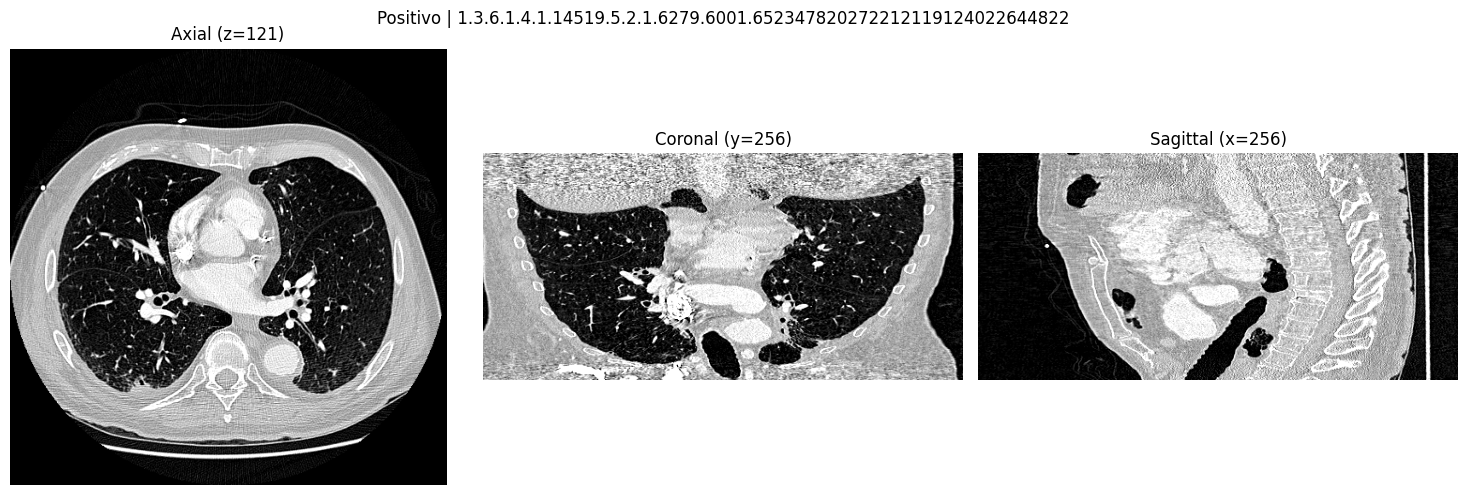

Ejemplo negativo:


seriesuid              1.3.6.1.4.1.14519.5.2.1.6279.6001.120196332569...
subset                                                           subset5
split                                                              train
label_volume_binary                                                    0
mhd_path               /mnt/d/Universidad/analitica/proyecto_analitic...
Name: 454, dtype: object

shape negativo [z,y,x]: (133, 512, 512)
spacing negativo [x,y,z]: (0.7617189884185791, 0.7617189884185791, 2.5)
intensidad min/max: -3024.0 2184.0


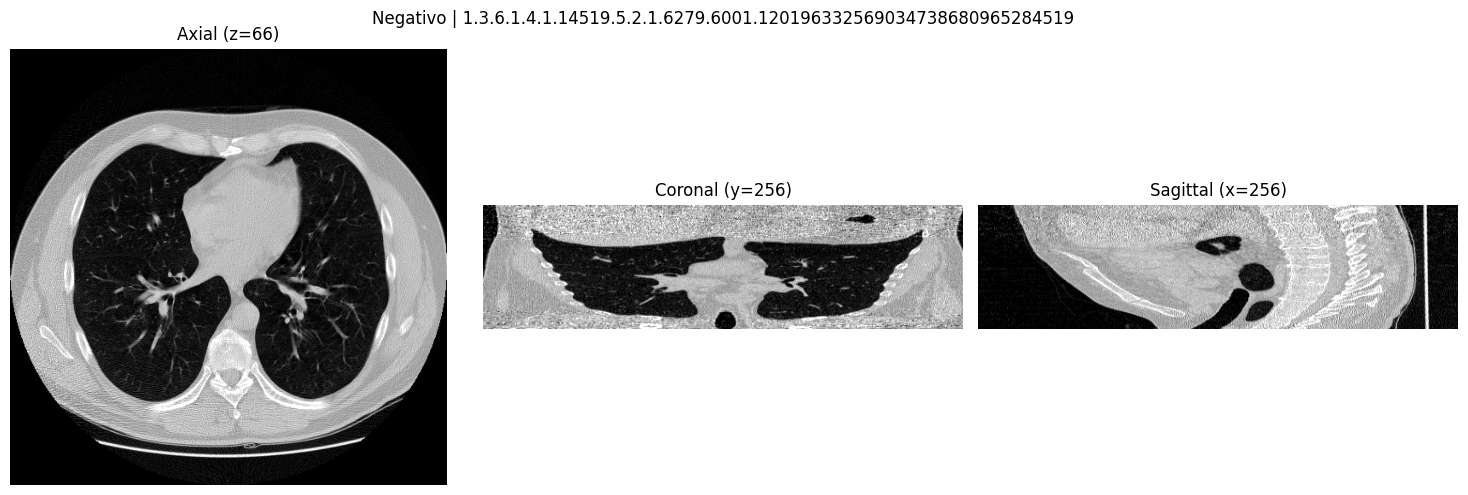

In [12]:
pos_row = manifest[manifest["label_volume_binary"] == 1].sample(1, random_state=SEED).iloc[0]
neg_row = manifest[manifest["label_volume_binary"] == 0].sample(1, random_state=SEED).iloc[0]

print("Ejemplo positivo:")
display(pos_row[["seriesuid", "subset", "split", "label_volume_binary", "mhd_path"]])

img_pos, vol_pos = read_volume(pos_row["mhd_path"])
print("shape positivo [z,y,x]:", vol_pos.shape)
print("spacing positivo [x,y,z]:", img_pos.GetSpacing())
print("intensidad min/max:", float(vol_pos.min()), float(vol_pos.max()))
show_orthogonal_views(vol_pos, title=f"Positivo | {pos_row['seriesuid']}")

print("Ejemplo negativo:")
display(neg_row[["seriesuid", "subset", "split", "label_volume_binary", "mhd_path"]])

img_neg, vol_neg = read_volume(neg_row["mhd_path"])
print("shape negativo [z,y,x]:", vol_neg.shape)
print("spacing negativo [x,y,z]:", img_neg.GetSpacing())
print("intensidad min/max:", float(vol_neg.min()), float(vol_neg.max()))
show_orthogonal_views(vol_neg, title=f"Negativo | {neg_row['seriesuid']}")

## función para extraer metadatos de un scan

In [13]:
def extract_scan_metadata(row):
    out = {
        "seriesuid": row["seriesuid"],
        "subset": row["subset"],
        "split": row["split"],
        "label_volume_binary": int(row["label_volume_binary"]),
        "mhd_path": row["mhd_path"],
    }

    try:
        image = sitk.ReadImage(str(row["mhd_path"]))
        volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [z, y, x]

        size_x, size_y, size_z = image.GetSize()
        spacing_x, spacing_y, spacing_z = image.GetSpacing()
        origin_x, origin_y, origin_z = image.GetOrigin()

        out.update({
            "read_ok": 1,
            "size_x": int(size_x),
            "size_y": int(size_y),
            "size_z": int(size_z),
            "shape_z": int(volume.shape[0]),
            "shape_y": int(volume.shape[1]),
            "shape_x": int(volume.shape[2]),
            "spacing_x": float(spacing_x),
            "spacing_y": float(spacing_y),
            "spacing_z": float(spacing_z),
            "origin_x": float(origin_x),
            "origin_y": float(origin_y),
            "origin_z": float(origin_z),
            "int_min": float(volume.min()),
            "int_max": float(volume.max()),
            "int_mean": float(volume.mean()),
            "int_std": float(volume.std()),
            "p01": float(np.percentile(volume, 1)),
            "p50": float(np.percentile(volume, 50)),
            "p99": float(np.percentile(volume, 99)),
            "ratio_below_m1000": float((volume < -1000).mean()),
            "ratio_above_400": float((volume > 400).mean()),
        })
    except Exception as e:
        out.update({
            "read_ok": 0,
            "error": str(e),
        })

    return out

## calcular o cargar cache de metadatos

In [14]:
RECOMPUTE_METADATA = False

if EDA_CACHE_PATH.exists() and not RECOMPUTE_METADATA:
    metadata_df = pd.read_csv(EDA_CACHE_PATH)
    print("Metadatos cargados desde cache:", metadata_df.shape)
else:
    records = manifest.to_dict(orient="records")

    if tqdm is not None:
        iterator = tqdm(records, total=len(records), desc="Extrayendo metadatos")
    else:
        iterator = records

    metadata_rows = [extract_scan_metadata(row) for row in iterator]
    metadata_df = pd.DataFrame(metadata_rows)
    metadata_df.to_csv(EDA_CACHE_PATH, index=False)
    print("Metadatos calculados y guardados en:", EDA_CACHE_PATH)

display(metadata_df.head())

Extrayendo metadatos: 100%|██████████| 623/623 [28:04<00:00,  2.70s/it]

Metadatos calculados y guardados en: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/luna16/luna16_scan_metadata.csv


,seriesuid,subset,split,label_volume_binary,mhd_path,read_ok,size_x,size_y,size_z,shape_z,...,origin_z,int_min,int_max,int_mean,int_std,p01,p50,p99,ratio_below_m1000,ratio_above_400
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,subset0,train,0,/mnt/d/Universidad/analitica/proyecto_analitic...,1,512,512,121,121,...,-335.209991,-3024.0,2103.0,-1035.624878,1126.599609,-3024.0,-913.0,490.0,0.323599,0.014456
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,subset0,train,1,/mnt/d/Universidad/analitica/proyecto_analitic...,1,512,512,119,119,...,-313.750000,-2048.0,3071.0,-768.508057,797.659180,-2048.0,-844.0,507.0,0.231710,0.015564
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,subset0,test,1,/mnt/d/Universidad/analitica/proyecto_analitic...,1,512,512,161,161,...,-194.000000,-3024.0,2211.0,-869.395386,1193.139771,-3024.0,-348.0,635.0,0.276744,0.028933
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,subset0,train,1,/mnt/d/Universidad/analitica/proyecto_analitic...,1,512,512,538,538,...,-298.774994,-3024.0,2054.0,-892.303284,1179.265869,-3024.0,-320.0,475.0,0.242664,0.014125
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896...,subset0,val,0,/mnt/d/Universidad/analitica/proyecto_analitic...,1,512,512,124,124,...,-337.480011,-3024.0,3071.0,-1024.475586,1123.631348,-3024.0,-884.0,382.0,0.291555,0.008984


## sanity check de lectura

In [15]:
print("Distribución read_ok:")
print(metadata_df["read_ok"].value_counts(dropna=False))

metadata_ok = metadata_df[metadata_df["read_ok"] == 1].copy()
print("\nShape metadata_ok:", metadata_ok.shape)

Distribución read_ok:
read_ok
1    623
Name: count, dtype: int64

Shape metadata_ok: (623, 27)


## estadísticas descriptivas principales

In [16]:
cols_resume = [
    "shape_z", "shape_y", "shape_x",
    "spacing_x", "spacing_y", "spacing_z",
    "int_min", "int_max", "int_mean", "int_std",
    "p01", "p50", "p99"
]

display(metadata_ok[cols_resume].describe().T)

,count,mean,std,min,25%,50%,75%,max
shape_z,623.0,259.945425,136.275705,95.000000,140.000000,238.000000,303.000000,764.000000
shape_y,623.0,512.000000,0.000000,512.000000,512.000000,512.000000,512.000000,512.000000
shape_x,623.0,512.000000,0.000000,512.000000,512.000000,512.000000,512.000000,512.000000
spacing_x,623.0,0.686984,0.085532,0.488281,0.625000,0.703125,0.742188,0.976562
spacing_y,623.0,0.686984,0.085532,0.488281,0.625000,0.703125,0.742188,0.976562
spacing_z,623.0,1.542416,0.721720,0.450000,1.000000,1.250000,2.500000,2.500000
int_min,623.0,-2325.951846,1561.176594,-32768.000000,-3024.000000,-2048.000000,-1024.000000,-1000.000000
int_max,623.0,2789.468700,2093.518072,1395.000000,2056.000000,3000.000000,3071.000000,32767.000000
int_mean,623.0,-784.710021,212.041827,-1406.906982,-947.656189,-847.769836,-587.929871,-211.827698
int_std,623.0,886.481251,285.495375,386.954163,511.550491,823.503845,1158.293457,1244.194458


## histogramas de tamaño y spacing

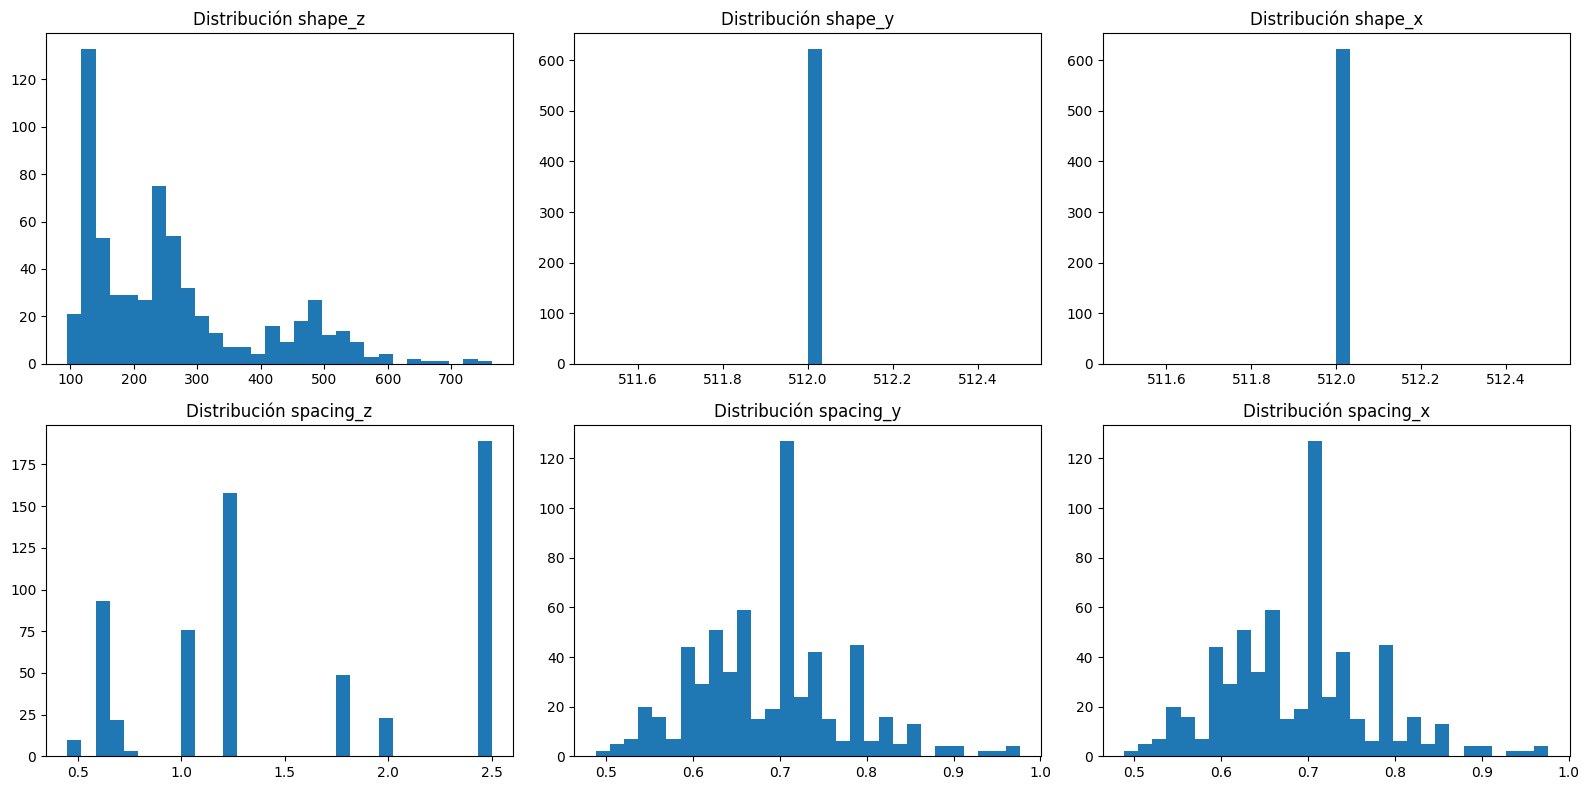

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(metadata_ok["shape_z"], bins=30)
axes[0, 0].set_title("Distribución shape_z")

axes[0, 1].hist(metadata_ok["shape_y"], bins=30)
axes[0, 1].set_title("Distribución shape_y")

axes[0, 2].hist(metadata_ok["shape_x"], bins=30)
axes[0, 2].set_title("Distribución shape_x")

axes[1, 0].hist(metadata_ok["spacing_z"], bins=30)
axes[1, 0].set_title("Distribución spacing_z")

axes[1, 1].hist(metadata_ok["spacing_y"], bins=30)
axes[1, 1].set_title("Distribución spacing_y")

axes[1, 2].hist(metadata_ok["spacing_x"], bins=30)
axes[1, 2].set_title("Distribución spacing_x")

plt.tight_layout()
plt.show()

## histogramas de intensidad

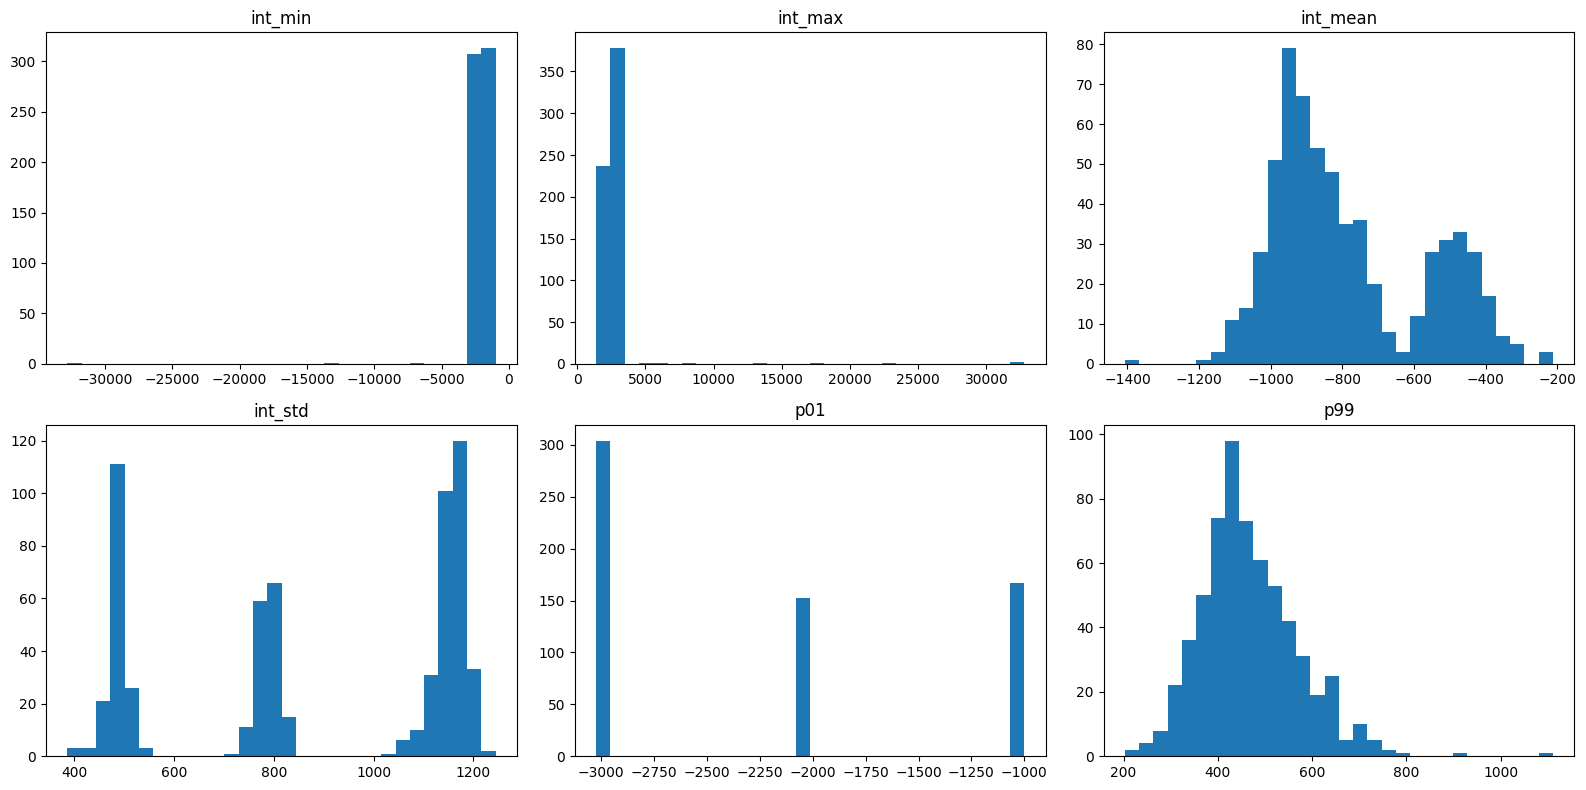

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(metadata_ok["int_min"], bins=30)
axes[0, 0].set_title("int_min")

axes[0, 1].hist(metadata_ok["int_max"], bins=30)
axes[0, 1].set_title("int_max")

axes[0, 2].hist(metadata_ok["int_mean"], bins=30)
axes[0, 2].set_title("int_mean")

axes[1, 0].hist(metadata_ok["int_std"], bins=30)
axes[1, 0].set_title("int_std")

axes[1, 1].hist(metadata_ok["p01"], bins=30)
axes[1, 1].set_title("p01")

axes[1, 2].hist(metadata_ok["p99"], bins=30)
axes[1, 2].set_title("p99")

plt.tight_layout()
plt.show()

## comparación por clase

In [19]:
group_stats = (
    metadata_ok.groupby("label_volume_binary")[
        ["shape_z", "spacing_z", "int_mean", "int_std", "p01", "p99"]
    ]
    .agg(["mean", "std", "median"])
)

display(group_stats)

shape_z                    spacing_z                   \
                           mean         std median      mean       std median   
label_volume_binary                                                             
0                    237.282051  136.345519  190.0  1.712436  0.747958   1.80   
1                    270.271028  135.146157  245.0  1.464953  0.696681   1.25   

                       int_mean                             int_std  \
                           mean         std      median        mean   
label_volume_binary                                                   
0                   -840.620342  197.733181 -916.606750  974.634375   
1                   -759.236861  213.665588 -812.667145  846.318028   

                                                      p01                      \
                            std       median         mean         std  median   
label_volume_binary                                                             
0                    268.106185  1144.335205 -2504.348718  780.651790 -3024.0   
1                    284.440752   801.673645 -2130.535047  846.271044 -2048.0   

                            p99                     
                           mean         std median  
label_volume_binary                                 
0                    448.615385   99.199324  438.0  
1                    475.397196  104.894443  459.0

## boxplots por clase

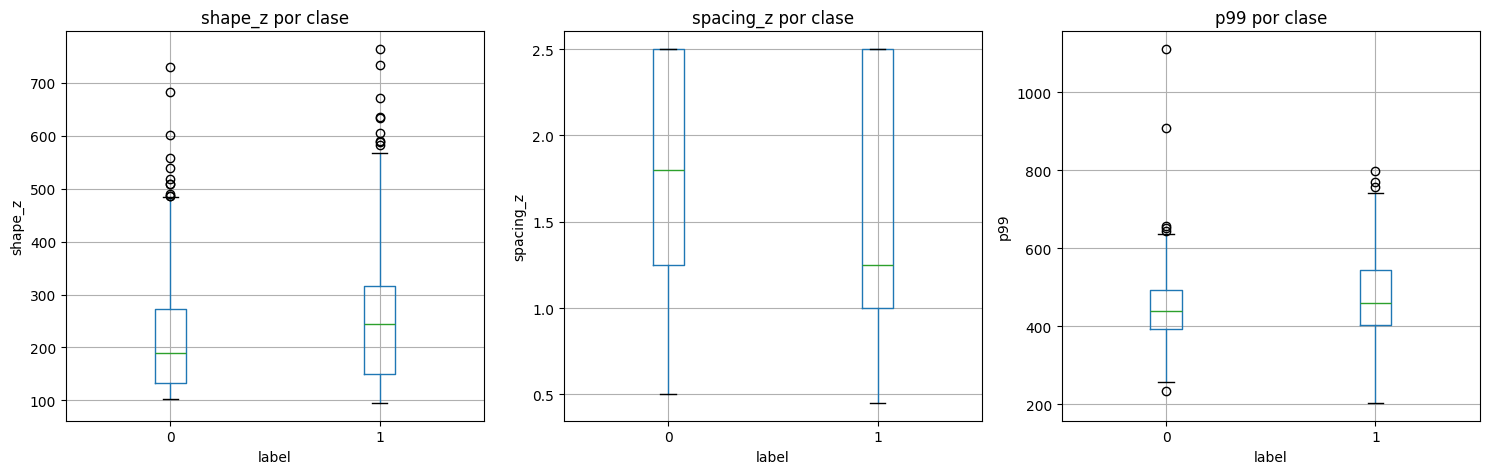

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metadata_ok.boxplot(column="shape_z", by="label_volume_binary", ax=axes[0])
axes[0].set_title("shape_z por clase")
axes[0].set_xlabel("label")
axes[0].set_ylabel("shape_z")

metadata_ok.boxplot(column="spacing_z", by="label_volume_binary", ax=axes[1])
axes[1].set_title("spacing_z por clase")
axes[1].set_xlabel("label")
axes[1].set_ylabel("spacing_z")

metadata_ok.boxplot(column="p99", by="label_volume_binary", ax=axes[2])
axes[2].set_title("p99 por clase")
axes[2].set_xlabel("label")
axes[2].set_ylabel("p99")

plt.suptitle("")
plt.tight_layout()
plt.show()

## guardar tablas resumen de EDA

In [21]:
eda_summary_basic_path = LUNA16_WORKING_DIR / "luna16_eda_basic_counts.csv"
eda_subset_path = LUNA16_WORKING_DIR / "luna16_eda_subset_vs_class.csv"
eda_split_path = LUNA16_WORKING_DIR / "luna16_eda_split_vs_class.csv"

basic_counts_df = pd.DataFrame({
    "metric": [
        "n_scans",
        "n_positive",
        "n_negative",
        "n_train",
        "n_val",
        "n_test",
    ],
    "value": [
        len(manifest),
        int((manifest["label_volume_binary"] == 1).sum()),
        int((manifest["label_volume_binary"] == 0).sum()),
        int((manifest["split"] == "train").sum()),
        int((manifest["split"] == "val").sum()),
        int((manifest["split"] == "test").sum()),
    ]
})

basic_counts_df.to_csv(eda_summary_basic_path, index=False)
ct_subset.to_csv(eda_subset_path)
ct_split.to_csv(eda_split_path)

print("Guardado:")
print(" -", eda_summary_basic_path)
print(" -", eda_subset_path)
print(" -", eda_split_path)
print(" -", EDA_CACHE_PATH)

Guardado:
 - /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/luna16/luna16_eda_basic_counts.csv
 - /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/luna16/luna16_eda_subset_vs_class.csv
 - /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/luna16/luna16_eda_split_vs_class.csv
 - /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/luna16/luna16_scan_metadata.csv


## conclusión automática rápida del EDA

In [22]:
print("Resumen rápido LUNA16 EDA")
print("-" * 40)
print("Scans analizados:", len(metadata_ok))
print("Positivos:", int((metadata_ok["label_volume_binary"] == 1).sum()))
print("Negativos:", int((metadata_ok["label_volume_binary"] == 0).sum()))
print("shape_z mediana:", round(metadata_ok["shape_z"].median(), 2))
print("spacing_z mediana:", round(metadata_ok["spacing_z"].median(), 4))
print("p01 mediana:", round(metadata_ok["p01"].median(), 2))
print("p99 mediana:", round(metadata_ok["p99"].median(), 2))

Resumen rápido LUNA16 EDA
----------------------------------------
Scans analizados: 623
Positivos: 428
Negativos: 195
shape_z mediana: 238.0
spacing_z mediana: 1.25
p01 mediana: -2048.0
p99 mediana: 452.0
